Import things

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import emcee

In [4]:
def plotparams(ax, labelsize=15):
    '''
    Basic plot params

    :param ax: axes to modify

    :type ax: matplotlib axes object

    :returns: modified matplotlib axes object
    '''
    ax.minorticks_on()
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(direction='in', which='both', labelsize=labelsize)
    ax.tick_params('both', length=8, width=1.8, which='major')
    ax.tick_params('both', length=4, width=1, which='minor')
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(1.5)
    return ax

Text(0, 0.5, 'Radial Velocity [km/s]')

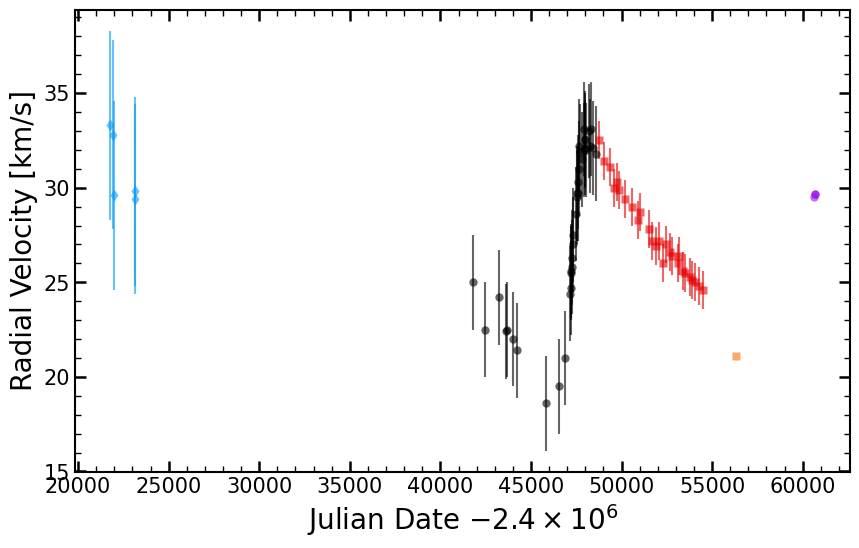

In [5]:
df = pd.read_csv('HD104438_RVs.csv')

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax = plotparams(ax)

instrument_weights = {
    1.0: 'CORAVEL',
    0.25: 'Cambridge Spectrometer',
    0.025: 'Mount Wilson 60inch'
}

rv_err_weights = {
    1.0: 1,
    0.25: 2.5,
    0.025: 5.0
}

df['Instrument'] = df.Weight.map(instrument_weights)
df['RV_err'] = df.Weight.map(rv_err_weights)

df_apogee = pd.DataFrame({'JD':[2456337.762], 'RV': [21.105],
                          'RV_err':[0.02474], 'Instrument':['APOGEE'], 'Weight':[1.0]})

df_apf = pd.DataFrame({'JD':[2460648.893223666, 2460663.8506141417, 2460653.898714318],
                       'RV':[29.51, 29.68, 29.65]})
df_apf['Instrument'] = 'APF'
df_apf['Weight'] = 1.0

df = pd.concat([df, df_apogee, df_apf])

instrument_list = df.Instrument.value_counts().index
markers = ['o', 's', 'd', 'o', 's']
colors = ['black', 'xkcd:red', 'xkcd:azure', 'xkcd:violet', 'xkcd:orange']

for instrument, marker, color in zip(instrument_list, markers, colors):
    ax.errorbar(df[df.Instrument == instrument].JD - 2.4e6, df[df.Instrument == instrument].RV, 
                yerr=df[df.Instrument == instrument].RV_err, marker=marker, color=color, ls='',
                markeredgecolor='none', alpha=0.6)

ax.set_xlabel(r'Julian Date $ - 2.4\times10^6$', fontsize=20)
ax.set_ylabel('Radial Velocity [km/s]', fontsize=20)

__First, use MCMC methods to constrain the RV orbit__


In [93]:
# Define functions
def solve_kepler(M, e, tol=1e-10, max_iter=100):
    M = np.mod(M, 2 * np.pi)
    E = np.where(e < 0.8, M, np.pi * np.ones_like(M))  # Good initial guess

    for i in range(max_iter):
        f = E - e * np.sin(E) - M
        f_prime = 1 - e * np.cos(E)
        delta = f / f_prime
        E -= delta
        if np.all(np.abs(delta) < tol):
            break
    else:
        raise RuntimeError("Kepler solver failed to converge.")
    return E


def keplerian_model(t, P, K, e, gamma, omega_deg, T0):
    omega = np.radians(omega_deg)
    M = 2 * np.pi * (t - T0) / P
    E = solve_kepler(M, e)
    nu = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2),
                        np.sqrt(1 - e) * np.cos(E / 2))
    rv = gamma + K * (np.cos(omega + nu) + e * np.cos(omega))
    return rv


In [94]:
# Data

#np.random.seed(42)
#t = np.linspace(2390000, 2430000, 79)
P = 13000
K = 6.7
true_params = [0.58, 24.0, -80, 2394500.4]
rv_true = keplerian_model(t, P, K, *true_params)

t = df["JD"].values       # observation times
rv_obs = df["RV"].values    # observed RVs
#rv_err = df["Weight"].values  # uncertainties --> .025 corresponds to 0, .25 to 1.1, and 1 to 1.4 (what does 0 correspond to?)

rv_err= df['RV_err'].fillna(0)
#rv_err = np.full_like(rv_true, 1.1) # errors are all 1.1
#rv_obs = rv_true + np.random.normal(0, rv_err)

In [95]:
# Priors
def log_prior(theta):
    e, gamma, omega, T0 = theta
    if not (0.1 < e < 0.99):
        return -np.inf
    if not (0 <= gamma <= 40):
        return -np.inf
    if not (-180 <= omega <= 180):
        return -np.inf
    if not (2000000 <= T0 <= 2800000):
        return -np.inf
    return 0.0

# Likelihood
def log_likelihood(theta, t, rv_obs, rv_err):
    e, gamma, omega, T0 = theta
    model = keplerian_model(t, P, K, e, gamma, omega, T0)
    return -0.5 * np.sum(((rv_obs - model) / rv_err) ** 2 + np.log(2 * np.pi * rv_err**2))

def log_probability(theta, t, rv_obs, rv_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, rv_obs, rv_err)

In [97]:
# Set up MCMC
ndim = 4
nwalkers = 32
initial = np.array([0.58, 24.0, -80, 2394500.4])
spread = [0.005, 0.5, 2.0, 10.0]
pos = initial + spread * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(t, rv_obs, rv_err))
print("Running MCMC...")
sampler.run_mcmc(pos, 50000, progress=True)

Running MCMC...


100%|█████████████████████████████████████| 50000/50000 [09:50<00:00, 84.72it/s]


State([[ 4.66138895e-01  2.46904278e+01 -9.58478054e+01  2.39503857e+06]
 [ 4.52281703e-01  2.51745282e+01 -8.17933187e+01  2.39519220e+06]
 [ 4.40220713e-01  2.51884566e+01 -9.56053241e+01  2.39484930e+06]
 [ 4.78544500e-01  2.48795147e+01 -8.56365538e+01  2.39517909e+06]
 [ 4.51939862e-01  2.51071667e+01 -8.66487290e+01  2.39509029e+06]
 [ 4.56135270e-01  2.49531004e+01 -8.72117099e+01  2.39516936e+06]
 [ 5.06368184e-01  2.47262156e+01 -8.50575368e+01  2.39515867e+06]
 [ 4.53168392e-01  2.50490049e+01 -9.06097014e+01  2.39503391e+06]
 [ 4.50460856e-01  2.51834247e+01 -8.89320333e+01  2.39497330e+06]
 [ 4.45328541e-01  2.50818473e+01 -8.04333130e+01  2.39531302e+06]
 [ 4.68026040e-01  2.50163599e+01 -9.12174406e+01  2.39497022e+06]
 [ 4.46438940e-01  2.50713006e+01 -8.68891135e+01  2.39515113e+06]
 [ 4.52125777e-01  2.50538004e+01 -9.20531340e+01  2.39498304e+06]
 [ 4.57720409e-01  2.48796332e+01 -9.58602104e+01  2.39497040e+06]
 [ 4.59768751e-01  2.49696646e+01 -9.01833921e+01  2.395

In [83]:
# Analyze the data
samples = sampler.get_chain(discard=10000, thin=15, flat=True)
labels = ['e', 'gamma', 'omega', 'T0']
for i, name in enumerate(labels):
    mcmc = np.percentile(samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{name} = {mcmc[1]:.5f} (+{q[1]:.5f}, -{q[0]:.5f})")

e = 0.45689 (+0.01885, -0.01849)
gamma = 25.02390 (+0.15104, -0.14955)
omega = -87.91647 (+5.62589, -5.72843)
T0 = 2395103.97310 (+131.75150, -142.97828)


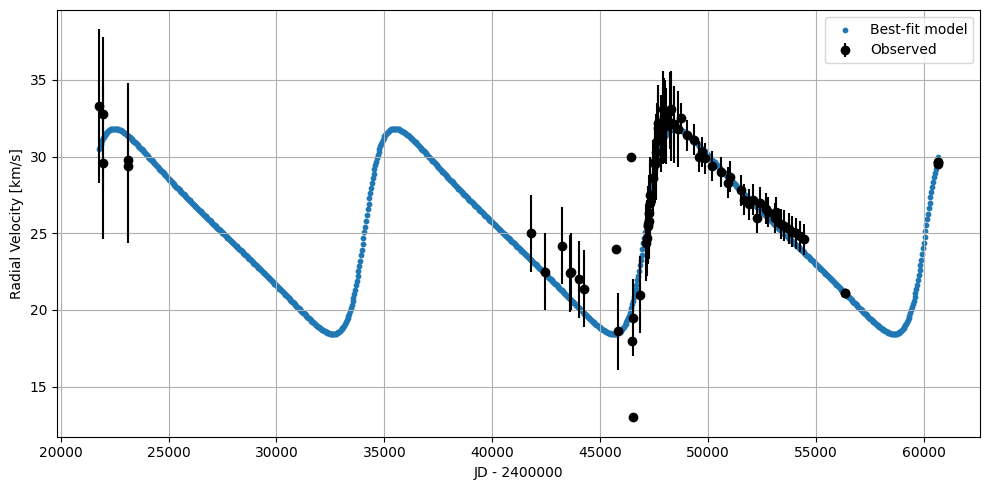

In [92]:
# RV Curve
best_fit = np.median(samples, axis=0)
t_fine = np.linspace(min(t), max(t), 1000)
rv_model = keplerian_model(t_fine, P, K, *best_fit)

plt.figure(figsize=(10, 5))
plt.errorbar(t - 2.4e6, rv_obs, yerr=rv_err, fmt='o', label='Observed', color='black')
plt.scatter(t_fine - 2.4e6, rv_model, label='Best-fit model', color='tab:blue', s=10)
plt.xlabel("JD - 2400000")
plt.ylabel("Radial Velocity [km/s]")

for instrument, marker, color in zip(instrument_list, markers, colors): #color code by instrument
    ax.errorbar(df[df.Instrument == instrument].JD - 2.4e6, df[df.Instrument == instrument].RV, 
                yerr=df[df.Instrument == instrument].RV_err, marker=marker, color=color, ls='',
                markeredgecolor='none', alpha=0.6) 

plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

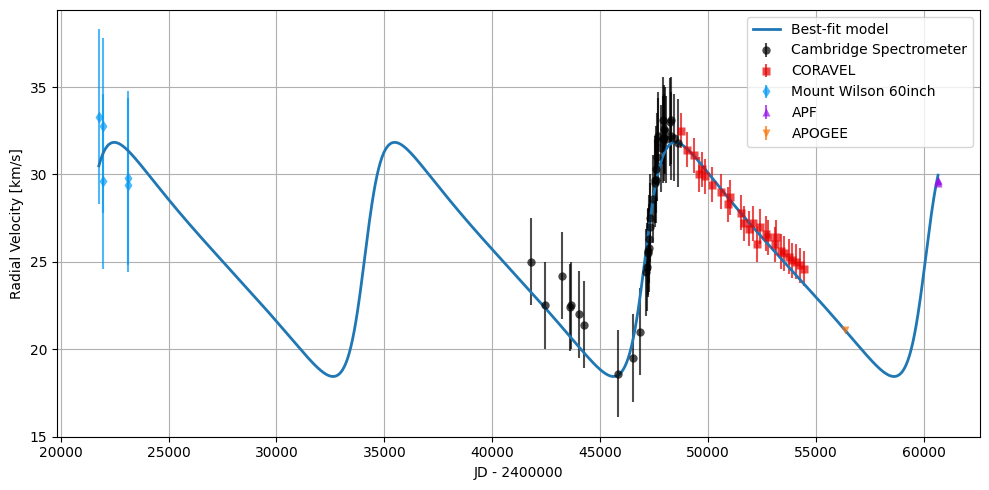

In [99]:
# Reuse the df from your previous snippet

# Generate best-fit model
# RV Curve
best_fit = np.median(samples, axis=0)
t_fine = np.linspace(min(t), max(t), 1000)
rv_model = keplerian_model(t_fine, P, K, *best_fit)

# Define markers and colors (update if needed to match all instruments)
instrument_list = df.Instrument.value_counts().index
markers = ['o', 's', 'd', '^', 'v', '*']  # Add more if needed
colors = ['black', 'xkcd:red', 'xkcd:azure', 'xkcd:violet', 'xkcd:orange', 'xkcd:green']

plt.figure(figsize=(10, 5))

# Plot observed data by instrument
for instrument, marker, color in zip(instrument_list, markers, colors):
    subdf = df[df.Instrument == instrument]
    plt.errorbar(
        subdf.JD - 2.4e6, subdf.RV, yerr=subdf.RV_err,
        fmt=marker, label=instrument, color=color, alpha=0.7,
        ls='', markeredgecolor='none'
    )

# Plot the best-fit Keplerian model
plt.plot(t_fine - 2.4e6, rv_model, label='Best-fit model', color='tab:blue', lw=2)

# Labels and legend
plt.xlabel("JD - 2400000")
plt.ylabel("Radial Velocity [km/s]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


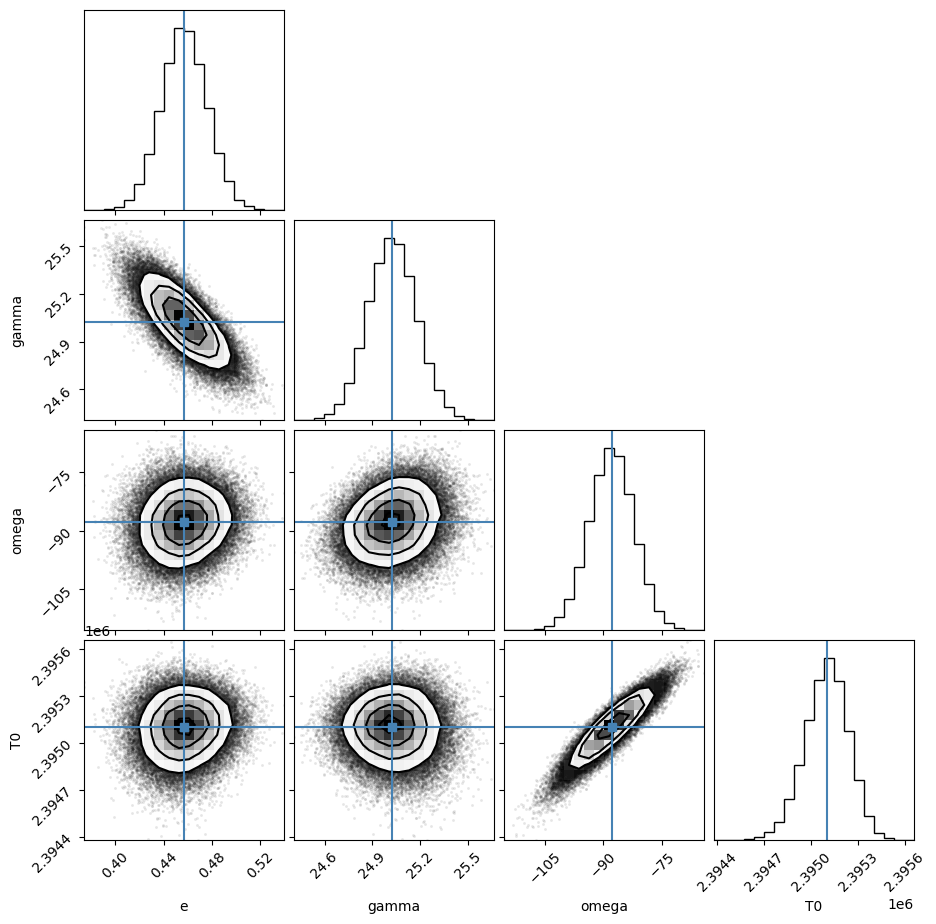

In [85]:
# Corner Plot
import corner
fig = corner.corner(samples, labels=labels, truths=best_fit)
plt.show()

In [86]:
# === Report Best-Fit Values with Uncertainties ===
labels = ['e', 'gamma', 'omega', 'T0']
samples = sampler.get_chain(discard=2000, thin=15, flat=True)

print("Best-fit parameters (with 1σ uncertainties):")
for i, label in enumerate(labels):
    median = np.percentile(samples[:, i], 50)
    lower = np.percentile(samples[:, i], 16)
    upper = np.percentile(samples[:, i], 84)
    print(f"{label:>6} = {median:.6f} (+{upper - median:.6f}, -{median - lower:.6f})")


Best-fit parameters (with 1σ uncertainties):
     e = 0.457008 (+0.018918, -0.018477)
 gamma = 25.023469 (+0.150177, -0.149716)
 omega = -87.894331 (+5.667384, -5.753600)
    T0 = 2395104.155347 (+132.738067, -142.431681)


In [91]:
def chi_squared(observed, model, errors):
    """Compute chi-squared statistic."""
   # errors = np.where(errors < 1e-10, 1e-10, errors)  # Set a lower limit on errors

    return np.sum(((observed - model) / errors) ** 2)


# === Compute best-fit model using median parameters ===
best_fit = np.median(samples, axis=0)
rv_model_best = keplerian_model(t, P, K, *best_fit)

# === Compute chi-squared and reduced chi-squared ===
chi2 = chi_squared(rv_obs, rv_model_best, rv_err)
dof = len(rv_obs) - len(best_fit)  # degrees of freedom: N_data - N_params
reduced_chi2 = chi2 / dof

print(f"Chi-squared: {chi2:.2f}")
print(f"Reduced Chi-squared (χ²/DOF): {reduced_chi2:.2f}")


Chi-squared: inf
Reduced Chi-squared (χ²/DOF): inf


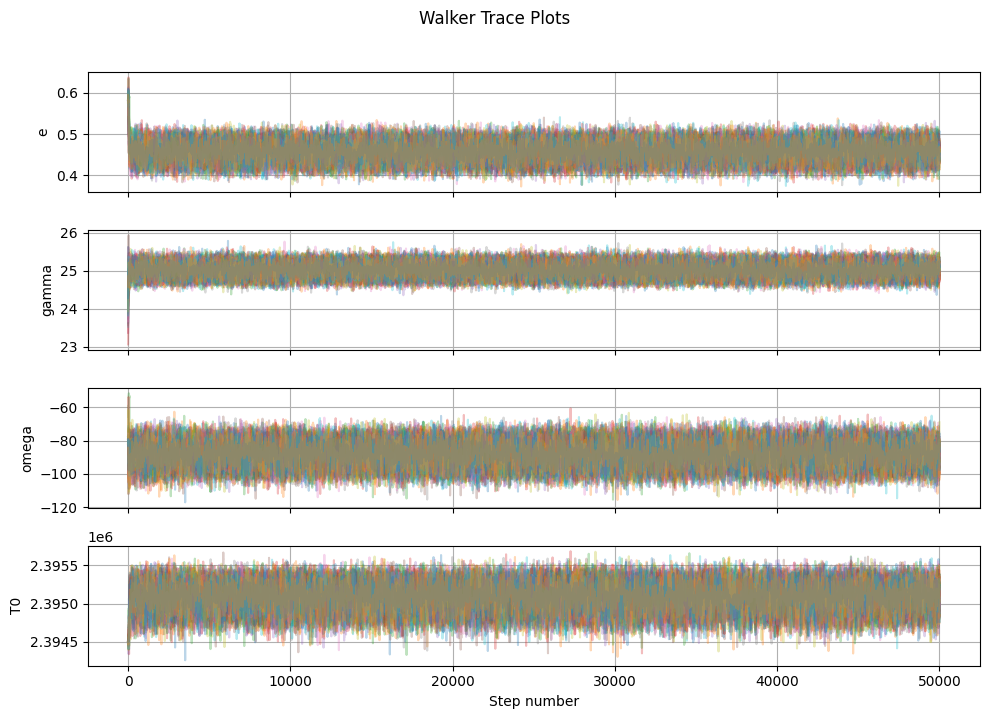

In [88]:
import matplotlib.pyplot as plt

# Get the full MCMC chain (shape: nsteps, nwalkers, ndim)
chain = sampler.get_chain()

labels = ['e', 'gamma', 'omega', 'T0']
nsteps, nwalkers, ndim = chain.shape

fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    for walker in range(nwalkers):
        ax.plot(chain[:, walker, i], alpha=0.3)
    ax.set_ylabel(labels[i])
    ax.grid(True)
axes[-1].set_xlabel('Step number')
plt.suptitle("Walker Trace Plots", y=1.02)
plt.tight_layout()
plt.show()
